# Kuvantunnistus omilla kuvilla - CNN

## Datan ymmärrys
Datasetti sisältää yhtensä 478 kuvaa ja kuusi luokkaa. Kuvien luokat ja niiden kuvamäärät ovat seuraavat:
- Omena: 52 kuvaa
- Avokaado: 50 kuvaa
- Banaani: 104 kuvaa
- Viinirypäle: 66 kuvaa
- Kiivi: 50 kuvaa
- Appelsiini: 158 kuvaa

## Datan esikäsittely
Kuvadata on jaettu valmiiksi 70%, 15%, 15% jaolla testi- validointi- ja koulutushakemistoon. Valmiin hakemistorakenteen avulla voidaan ladata data suoraan kolmeksi Dataset-olioksi `tf.keras.preprocessing.image_dataset_from_directory`-funktiolla. Funktion parametreina annetaan hakemistojen polku, kuvien koko, eräkoko, labelien muoto ja sekoitus, jolloin data kuvat sekoitetaan.  Eräkoko määritetään jo tässä vaiheessa, jolloin datasetti palauttaa erissä 32 kuvaa ja niiden vastaavat luokat. Tämän takia eräkokoa ei tarvitse määrittää enää mallin koulutuksen yhteydessä. 

Datasetti normalisoidaan jakamalla kuvat 255:llä. Datasetti jaetaan koulutus-, validointi- ja testidatasetteihin 70%, 15% ja 15% suhteessa.

In [56]:
import keras.src.callbacks
import tensorflow as tf
import numpy as np
from numpy.f2py.crackfortran import verbose
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, RandomFlip, RandomRotation, \
    RandomZoom
import random

batch_size = 32
img_size = (224, 224)

# Ladataan datasetti
train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "../datasets/kuvantunnistus/train",
    image_size=img_size,
    batch_size=batch_size,
    label_mode="categorical",
    shuffle=True,
)

validation_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "../datasets/kuvantunnistus/validation",
    image_size=img_size,
    batch_size=batch_size,
    label_mode="categorical",
    shuffle=True,
)

test_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "../datasets/kuvantunnistus/test",
    image_size=img_size,
    batch_size=batch_size,
    label_mode="categorical",
    shuffle=False,
)

class_names = train_dataset.class_names

# Normalisoidaan kuvat
train_dataset = train_dataset.map(lambda x, y: (x / 255.0, y))
validation_dataset = validation_dataset.map(lambda x, y: (x / 255.0, y))
test_dataset = test_dataset.map(lambda x, y: (x / 255.0, y))

# class names

# Tarkistetaan datasetin koko
print(f"Train batches: {len(train_dataset)}, Validation batches: {len(validation_dataset)}, Test batches: {len(test_dataset)}")

Found 216 files belonging to 6 classes.
Found 42 files belonging to 6 classes.
Found 42 files belonging to 6 classes.
Train batches: 7, Validation batches: 2, Test batches: 2


In [57]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
data_augmentation = Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.1),
    RandomZoom(0.2),
])

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    data_augmentation,
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(6, activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    #ReduceLROnPlateau(factor=0.1, patience=3)
]

model.summary()
history = model.fit(train_dataset, validation_data=validation_dataset, epochs=100, callbacks=callbacks, verbose=0)

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_10 (Sequential)      │ (None, 222, 222, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 186624)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 128)            │    23,888,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,908,166 (91.20 MB)

 Trainable params: 23,908,166 (91.20 MB)

 Non-trainable params: 0 (0.00 B)

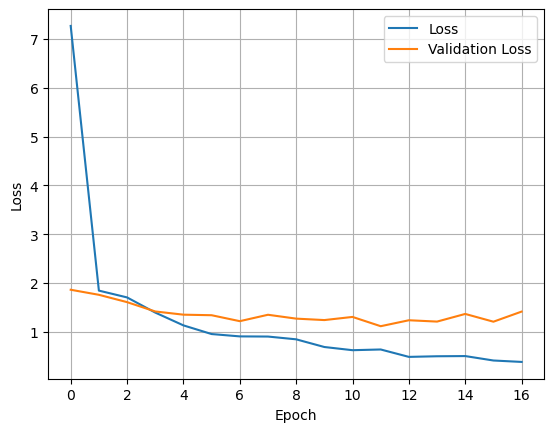

In [58]:
import matplotlib.pyplot as plt


def plot_loss(history):
    plt.plot(history.history["loss"], label="Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.legend()
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid()
    plt.show()

plot_loss(history)

In [59]:
def print_test_loss_accuracy(model):
    score = model.evaluate(test_dataset)
    print('Test loss:', score[0])
    print('Test accuracy:', score[1])

print_test_loss_accuracy(model)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5055 - loss: 1.2802
Test loss: 1.253788948059082
Test accuracy: 0.523809552192688


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step


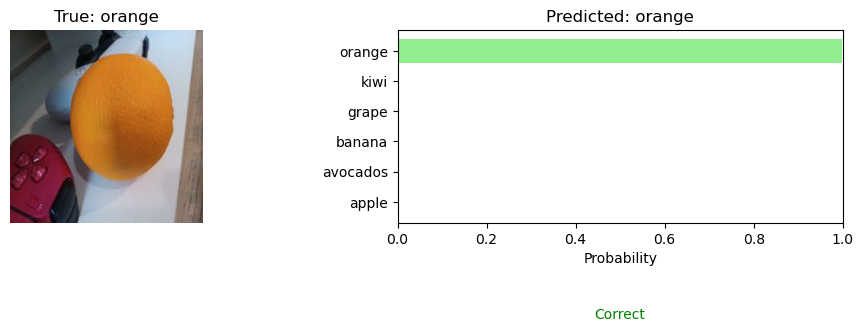

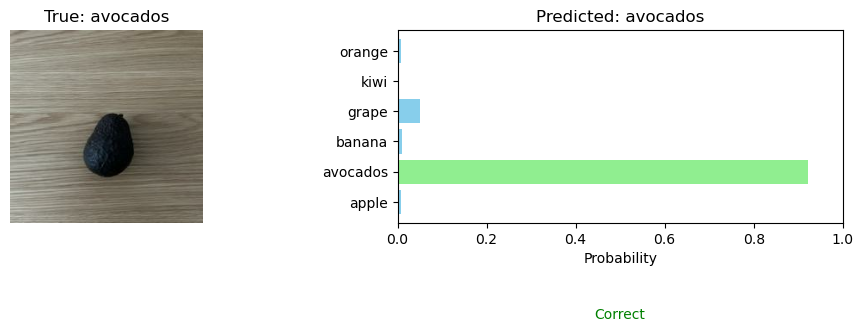

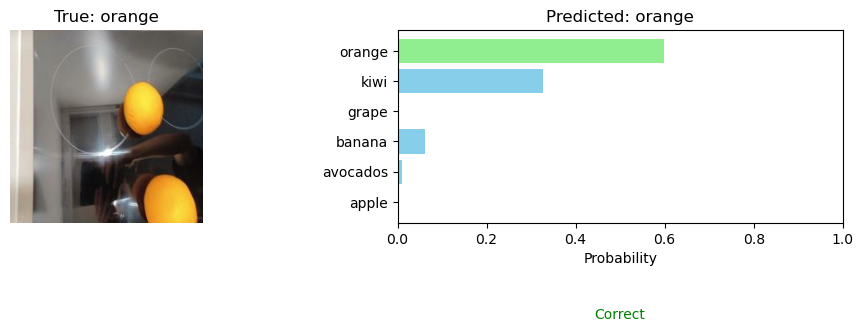

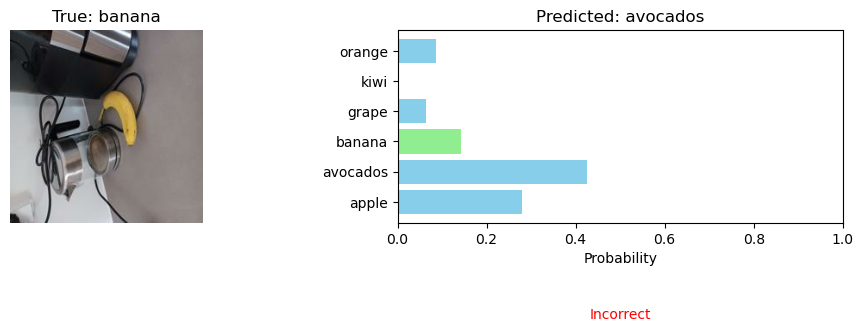

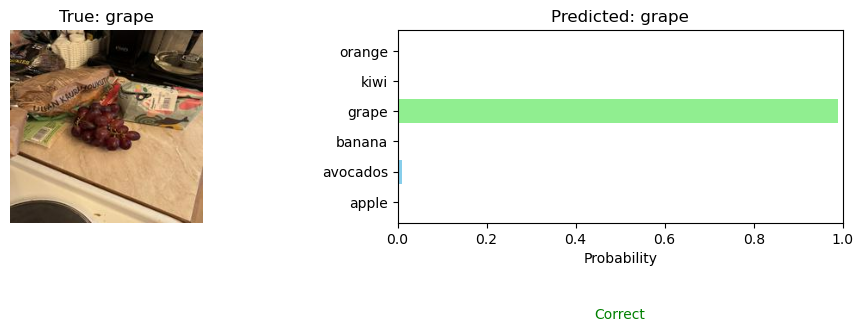

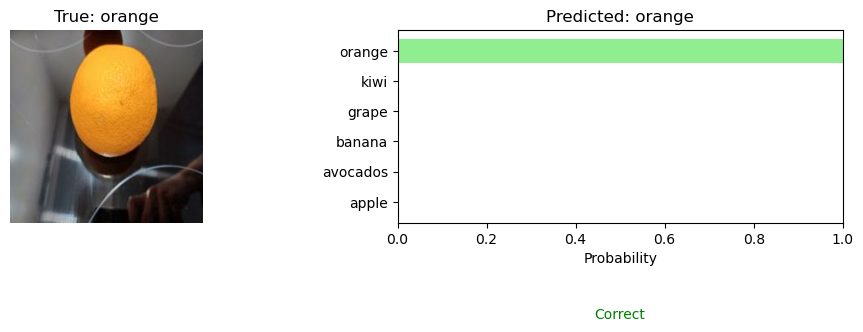

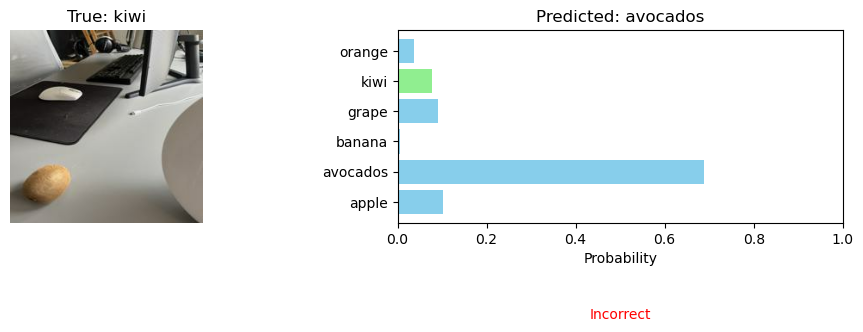

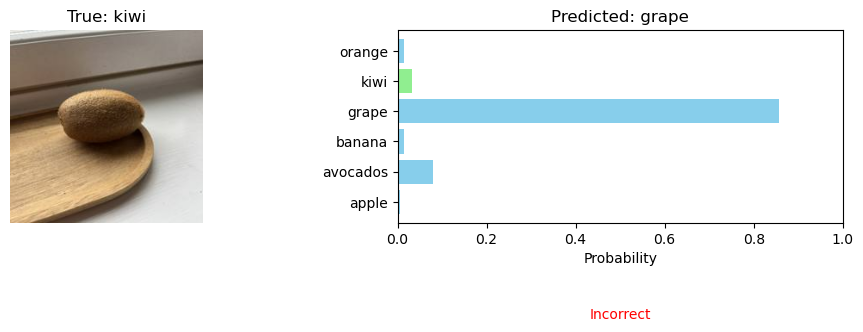

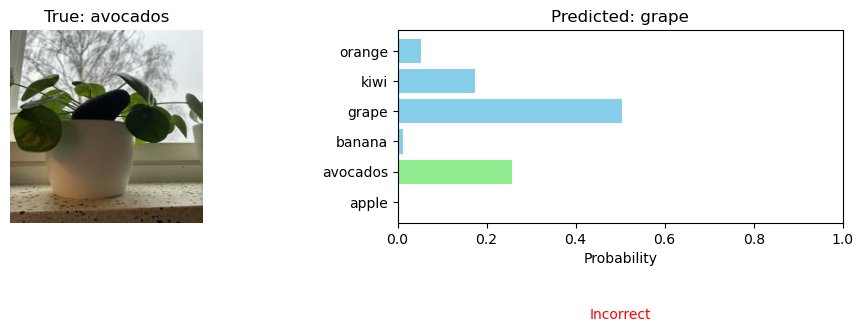

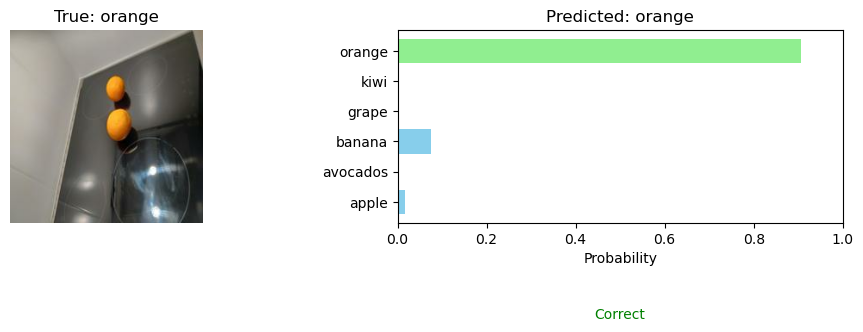

In [60]:
# Haetaan testidatasetista yksi batch
test_images, test_labels = next(iter(test_dataset.take(1)))

# Ennustetaan mallilla
predictions = model.predict(test_images)

# Muunnetaan one-hot-enkoodatut labelit kokonaisluvuiksi
true_labels = np.argmax(test_labels, axis=1)
predicted_labels = np.argmax(predictions, axis=1)


def plot_images(model):
    y_pred = []
    x_images = []
    y_true = []

    for images, labels in test_dataset:
        y_pred.extend(model.predict(images, batch_size=32))
        x_images.extend(images.numpy())
        y_true.extend(labels.numpy())

    y_pred = np.array(y_pred)
    y_true = np.array(y_true)
    x_images = np.array(x_images)

    num_samples = 10
    random_indices = random.sample(range(len(x_images)), num_samples)

    for i in random_indices:
        plt.figure(figsize=(10, 4))

        # Display image
        plt.subplot(1, 2, 1)
        plt.imshow((x_images[i] * 255).astype("uint8"))
        true_class = class_names[np.argmax(y_true[i])]
        plt.title(f"True: {true_class}")
        plt.axis('off')

        plt.subplot(1, 2, 2)
        pred_prob = y_pred[i]
        predicted_class = class_names[np.argmax(pred_prob)]

        colors = ['lightgreen' if (class_names[idx] == true_class) else 'skyblue'
                  for idx in range(len(class_names))]

        plt.barh(class_names, pred_prob, color=colors)
        plt.xlabel('Probability')
        plt.title(f"Predicted: {predicted_class}")
        plt.xlim([0, 1])

        if predicted_class != true_class:
            plt.text(0.5, -0.5, "Incorrect", color='red',
                     ha='center', transform=plt.gca().transAxes)
        else:
            plt.text(0.5, -0.5, "Correct", color='green',
                     ha='center', transform=plt.gca().transAxes)

        plt.tight_layout()
        plt.show()


plot_images(model)

# Kuvantunnistus omilla kuvilla - VGG16 Assisted
Luodaan malli VGG16:n avulla, joka on esikoulutettu ImageNet-datasetillä. Mallista jätetään pois viimeinen kerros, koska sen halutaan sopivan omaan datasettiin. Mallin kerrokset jäädytetään, jotta niitä ei kouluteta uudelleen. Mallin päälle lisätään oma toteutus.

In [61]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Flatten, Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.regularizers import l2

vgg16_base = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
vgg16_base.trainable = False

Luodaan omat kerrokset VGG16-mallin päälle. Mallin rakenne on seuraava:
- GlobalAveragePooling2D
- Dense(256, activation='relu')
- Dense(128, activation='relu', kernel_regularizer=l2(0.01))
- Dense(128, activation='relu')
- Dropout(0.2)
- Dense(6, activation='softmax')

In [62]:
x = vgg16_base.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dense(128, activation='relu', kernel_regularizer=l2(0.01))(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.2)(x)
predictions = Dense(6, activation='softmax')(x)

Rakennetaan malli VGG16:n ja omien kerrosten avulla. Mallin optimointimenetelmänä käytetään Adamia, häviönä categorical_crossentropy ja mittarina tarkkuus.
Koulutetaan mallia 10 epookkia, eräkoolla 32.

In [63]:
model2 = Model(inputs=vgg16_base.input, outputs=predictions)

model2.compile(optimizer='adam',
               loss='categorical_crossentropy',
               metrics=['accuracy'])

history2 = model2.fit(train_dataset, validation_data=validation_dataset, callbacks=callbacks, epochs=100, verbose=0)

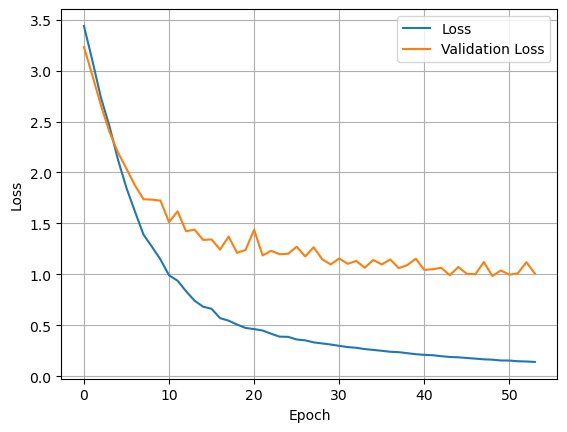

In [64]:
plot_loss(history2)

## Mallin Tarkkuuden arvointi
VGG-mallin tarkkuus testidatalla on noin 85% - 90%, joka on parempi kuin ensimmäisen.

In [65]:
print_test_loss_accuracy(model2)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.7946 - loss: 0.5640
Test loss: 0.5856971740722656
Test accuracy: 0.7857142686843872


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 905ms/step


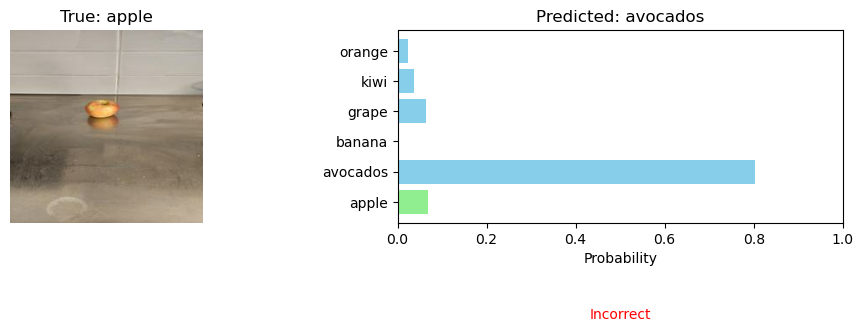

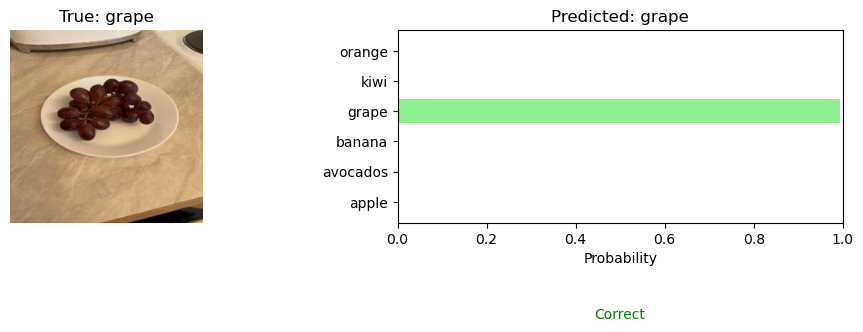

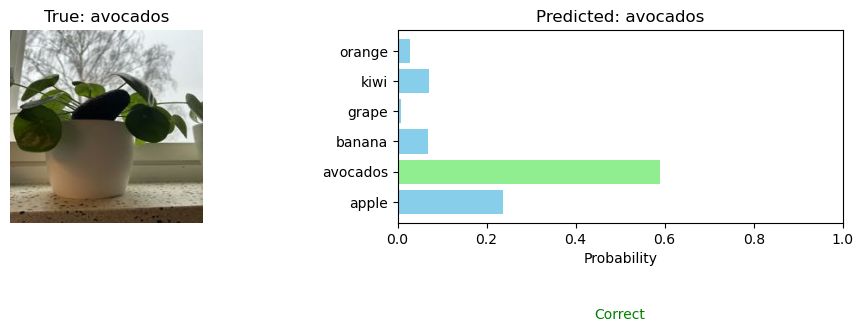

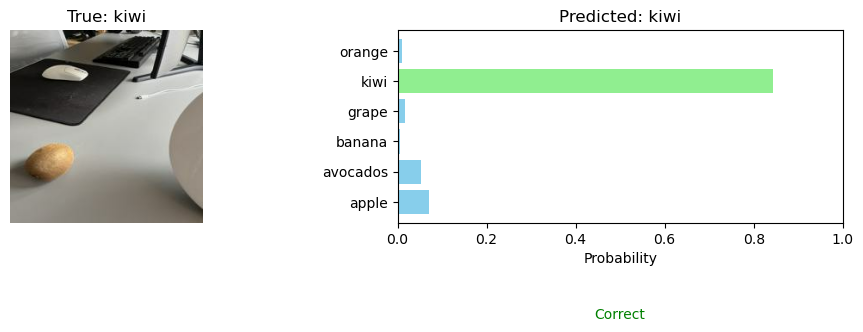

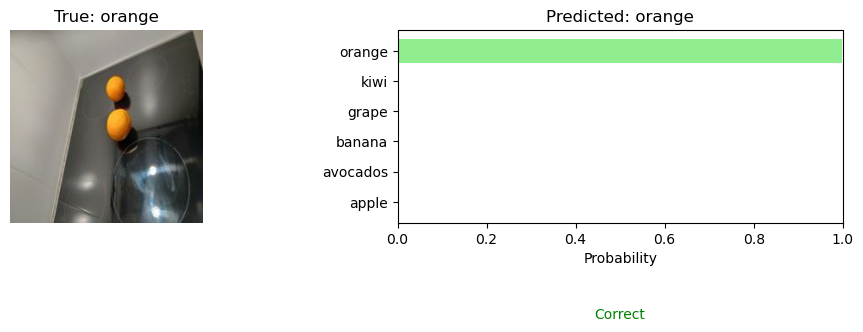

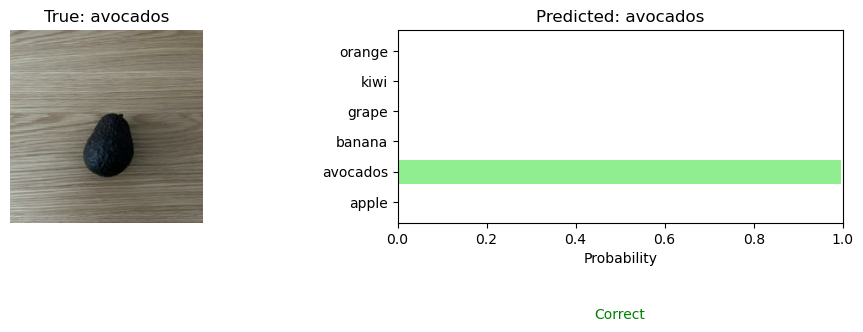

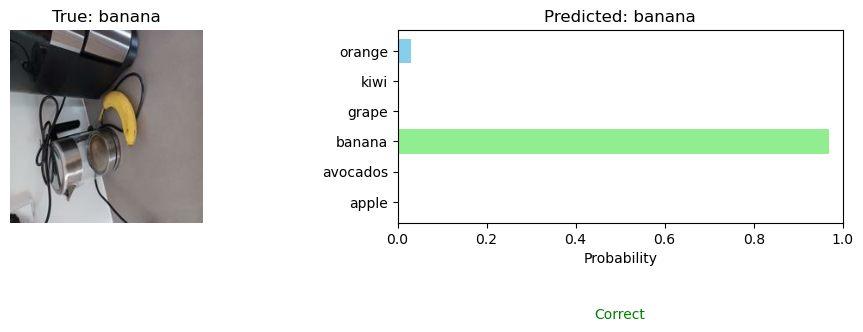

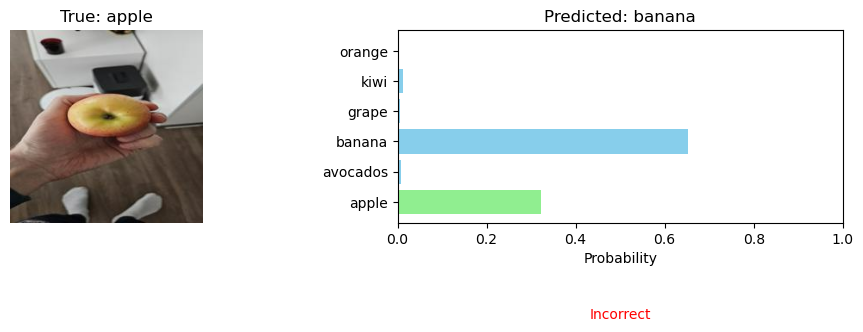

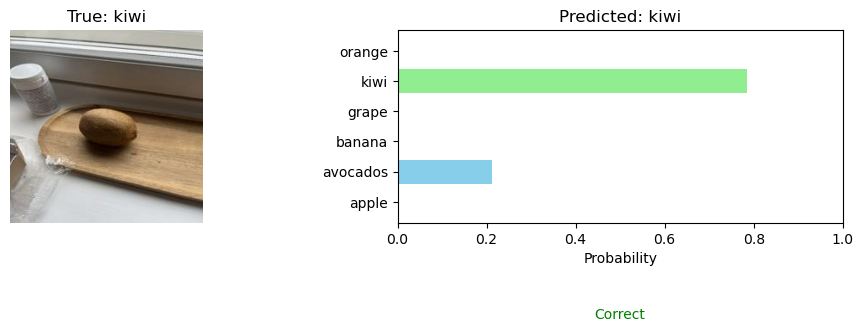

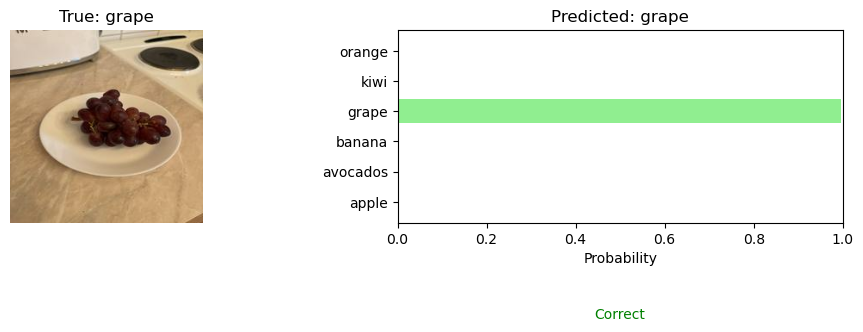

In [66]:
plot_images(model2)

# Hienosäädetty esikoulutettu malli VGG16

In [67]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam

# Load VGG16 base model
vgg16_base = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze initial layers and unfreeze later ones for fine-tuning
for layer in vgg16_base.layers[:15]:  # Freeze first 15 layers
    layer.trainable = False
for layer in vgg16_base.layers[15:]:  # Unfreeze last few layers
    layer.trainable = True

# Add custom layers
x = vgg16_base.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(6, activation='softmax')(x)

# Create model
model3 = Model(inputs=vgg16_base.input, outputs=predictions)

model3.summary()

optimizer = Adam(learning_rate=0.00001)  # Lower learning rate for fine-tuning

model3.compile(optimizer=optimizer,
               loss='categorical_crossentropy',
               metrics=['accuracy'])

history3 = model3.fit(train_dataset,
                      validation_data=validation_dataset,
                      epochs=100,  # More epochs for fine-tuning
                      callbacks=callbacks)

Model: "functional_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_20 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_8      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,847,558 (56.64 MB)

 Trainable params: 7,212,294 (27.51 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 571ms/step - accuracy: 0.1730 - loss: 2.0161 - val_accuracy: 0.1905 - val_loss: 1.8345
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 94ms/step - accuracy: 0.1657 - loss: 1.9020 - val_accuracy: 0.2857 - val_loss: 1.7964
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step - accuracy: 0.2234 - loss: 1.8395 - val_accuracy: 0.2857 - val_loss: 1.7653
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step - accuracy: 0.2513 - loss: 1.7879 - val_accuracy: 0.3571 - val_loss: 1.7337
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.2164 - loss: 1.7921 - val_accuracy: 0.3095 - val_loss: 1.7006
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step - accuracy: 0.2575 - loss: 1.7424 - val_accuracy: 0.3810 - val_loss: 1.6606
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step - accuracy: 0.3556 - loss: 1.5707 - val_accuracy: 0.4524 - val_loss: 1.6171
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step - accuracy: 0.3774 - loss: 1.5676 - val_accuracy: 0.5000 - val_loss

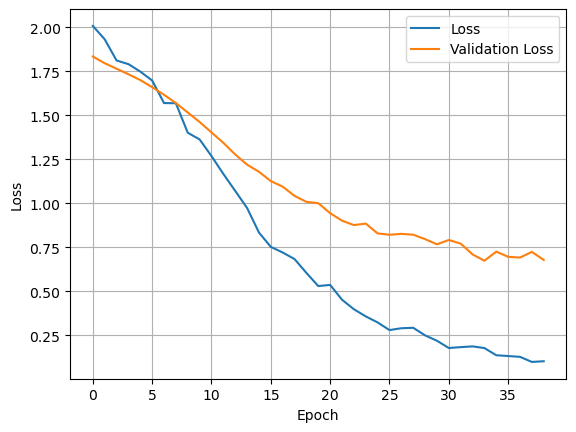

In [68]:
plot_loss(history3)

In [69]:
print_test_loss_accuracy(model3)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.8631 - loss: 0.4307
Test loss: 0.4482347071170807
Test accuracy: 0.8571428656578064


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 714ms/step


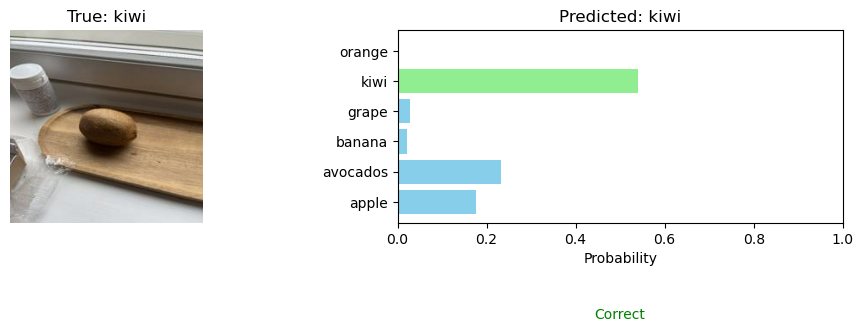

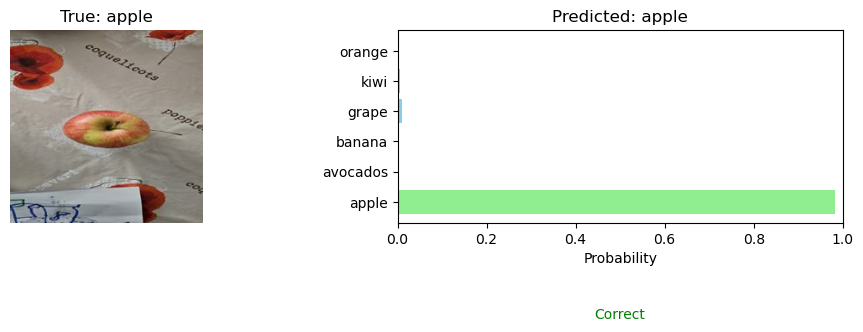

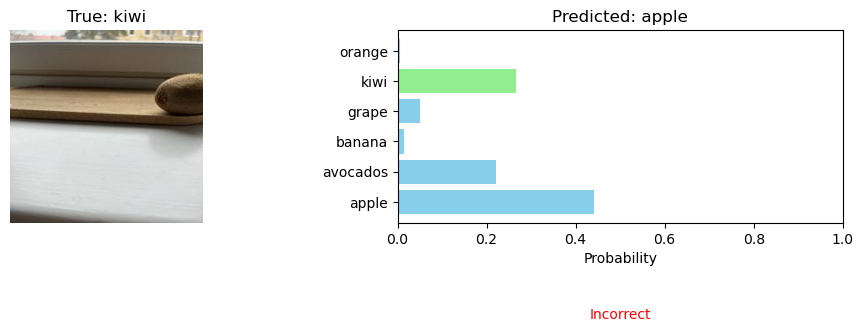

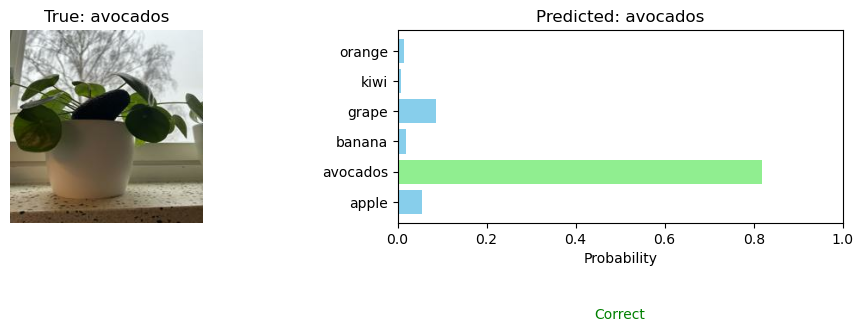

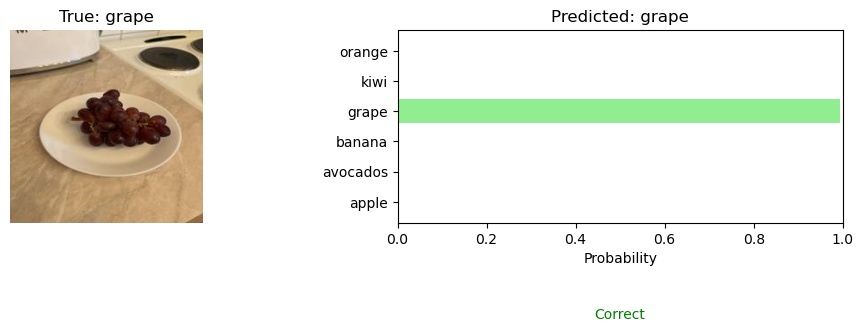

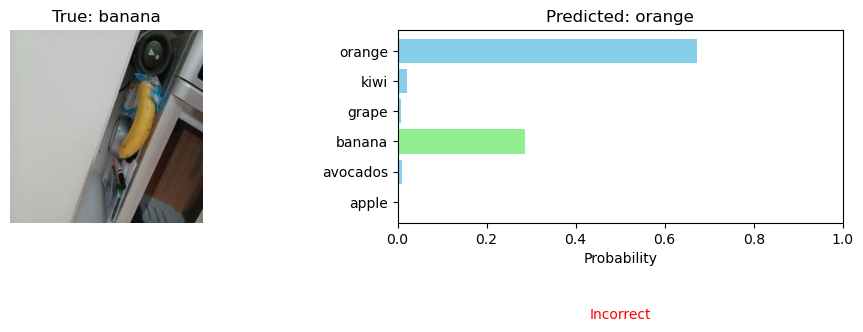

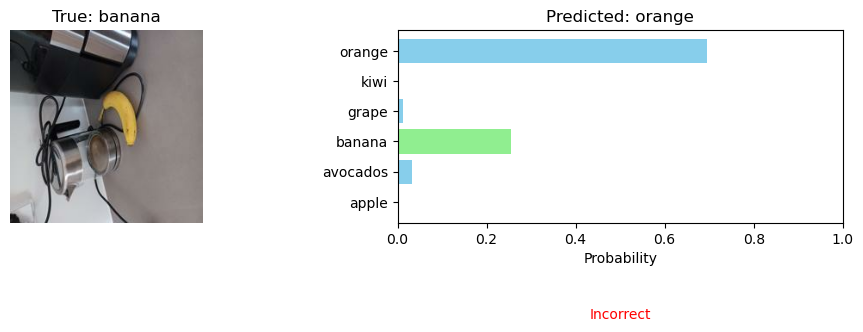

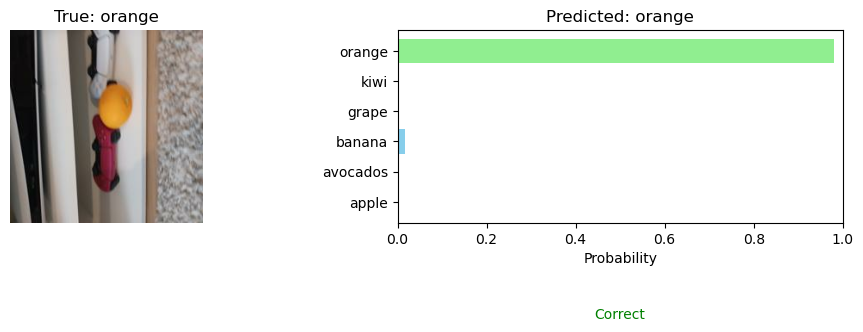

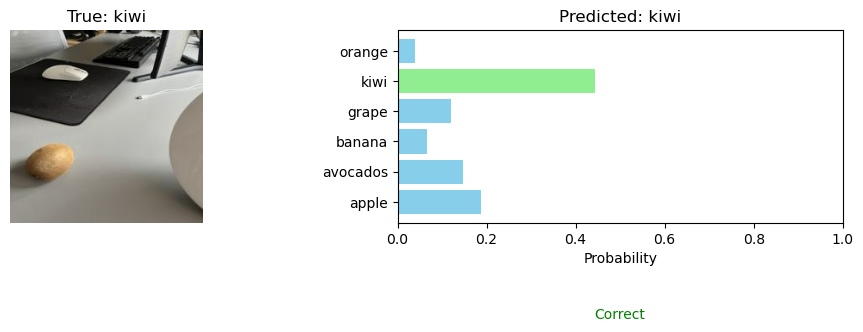

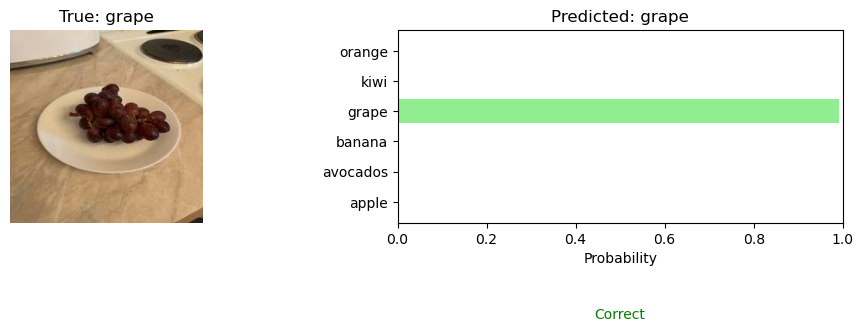

In [70]:
plot_images(model3)